## Statistical Approaches

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../dataset/cmi_internet_imputed.csv')


In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Number of numerical columns:", len(num_cols))
print(num_cols)

Number of numerical columns: 33
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_DEE', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time', 'sii']


In [4]:
if "sii" in num_cols:
    num_cols.remove("sii")

print("Number of numerical predictors:", len(num_cols))
print(num_cols)

Number of numerical predictors: 32
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_DEE', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time']


In [5]:
X_num = df[num_cols].copy()

print("Shape of X_num:", X_num.shape)
X_num.head()

Shape of X_num: (8460, 32)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time
0,5.0,0.0,51,46.000000,50.8,26.000000,69,5,87,114,...,9.21377,1,24.434900,8.895360,38.9177,19.541300,2.12927,60,3,448
1,9.0,0.0,66,48.000000,46.0,22.000000,75,5,70,122,...,3.97085,1,21.035200,14.974000,39.4497,15.410700,2.01000,64,0,434
2,10.0,1.0,71,56.500000,75.6,26.003679,65,5,94,117,...,16.17460,2,30.424101,32.959842,56.9964,33.418724,2.17000,54,2,453
3,9.0,0.0,71,56.000000,81.6,26.000000,60,6,97,117,...,18.82430,2,30.404100,16.779000,58.9338,26.479800,2.45100,45,0,577
4,18.0,1.0,65,62.206792,77.0,26.000000,68,5,80,116,...,16.17460,2,28.855800,23.975607,56.9964,33.915114,1.04000,58,1,433


In [6]:
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_num)

X_scaled = pd.DataFrame(

    X_scaled_array,

    columns=num_cols,

    index=df.index

)

X_scaled.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time
0,-1.466005,-0.820524,-0.498029,-1.557387,-0.864862,-0.281208,0.008791,0.102306,0.474905,-0.122860,...,-0.642638,-1.376198,-0.146057,-0.145012,-0.237738,-0.190245,-0.180229,0.200805,1.985105,0.088725
1,-0.346958,-0.820524,-0.031912,-1.278690,-0.987775,-1.456603,0.575074,0.102306,-1.100008,0.476259,...,-0.919715,-1.376198,-0.212004,-0.090573,-0.233311,-0.241430,-0.402756,0.617230,-0.969503,-0.073011
2,-0.067196,1.218734,0.123460,-0.094229,-0.229815,-0.280127,-0.368731,0.102306,1.123399,0.101810,...,-0.274774,0.442964,-0.029880,0.070505,-0.087305,-0.018283,-0.104238,-0.423833,1.000236,0.146488
3,-0.346958,-0.820524,0.123460,-0.163903,-0.076175,-0.281208,-0.840633,1.091463,1.401325,0.101810,...,-0.134744,0.442964,-0.030268,-0.074408,-0.071184,-0.104267,0.420034,-1.360791,-0.969503,1.579007
4,2.170899,1.218734,-0.062986,0.701003,-0.193966,-0.281208,-0.085589,0.102306,-0.173589,0.026920,...,-0.274774,0.442964,-0.060302,-0.009956,-0.087305,-0.012132,-2.212521,-0.007408,0.015367,-0.084563


### Z-score method

In [9]:
#applying the Z-score method to identify outliers
from scipy import stats
z_scores = pd.DataFrame(
    stats.zscore(X, nan_policy="omit"),
    columns=num_cols,
    index=df.index
)
z_scores.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time,sii
0,-1.466005,-0.820524,-0.498013,-1.557409,-0.864848,-0.281158,0.008835,0.102005,0.474900,-0.122879,...,-1.375678,-0.147202,-0.145140,-0.237769,-0.189612,-0.180694,0.200873,1.985093,0.088778,2.128877
1,-0.346958,-0.820524,-0.031901,-1.278714,-0.987759,-1.456477,0.575087,0.102005,-1.099996,0.476246,...,-1.375678,-0.213382,-0.090231,-0.233342,-0.240660,-0.402784,0.617237,-0.969843,-0.072985,-0.607211
2,-0.067196,1.218734,0.123470,-0.094260,-0.229808,-0.286183,-0.368666,0.102005,1.123386,0.101793,...,0.443649,-0.060075,0.020440,-0.087325,-0.047041,-0.104271,-0.423672,1.000114,0.146551,-0.607211
3,-0.346958,-0.820524,0.123470,-0.163933,-0.076169,-0.281158,-0.840542,1.091641,1.401309,0.101793,...,0.443649,-0.031003,-0.073927,-0.071203,-0.103863,0.419992,-1.360491,-0.969843,1.579309,0.760833
4,2.170899,1.218734,-0.062975,0.701916,-0.193958,-0.281158,-0.085540,0.102005,-0.173587,0.026902,...,0.443649,-0.061143,-0.008977,-0.087325,-0.013130,-2.212518,-0.007309,0.015136,-0.084539,-0.607211


In [10]:
#flagging outliers based on Z-score threshold (e.g., 3) and count them
z_threshold = 3
z_outliers = (z_scores.abs() > z_threshold).any(axis=1)
z_outliers.value_counts()

False    6250
True     2210
Name: count, dtype: int64

### Grubbs Test

In [7]:
def grubbs_test_once(x, alpha=0.05):
    """
    Performs one iteration of the two-sided Grubbs' test.

    Parameters
    ----------
    x : array-like
        One numerical variable.

    alpha : float, default=0.05
        Significance level.

    Returns
    -------
    result : dict
        Dictionary containing:
        - G statistic
        - critical value
        - index of the most extreme observation
        - value of the most extreme observation
        - whether it is an outlier
    """

    x = pd.Series(x).dropna()
    n = len(x)

    if n < 3:
        return {
            "G": np.nan,
            "G_critical": np.nan,
            "outlier_index": None,
            "outlier_value": np.nan,
            "is_outlier": False
        }

    mean_x = x.mean()
    std_x = x.std(ddof=1)

    if std_x == 0:
        return {
            "G": 0,
            "G_critical": np.nan,
            "outlier_index": None,
            "outlier_value": np.nan,
            "is_outlier": False
        }

    absolute_deviation = np.abs(x - mean_x)

    outlier_index = absolute_deviation.idxmax()
    outlier_value = x.loc[outlier_index]

    G = absolute_deviation.loc[outlier_index] / std_x

    # Two-sided Grubbs test critical value
    t_critical = stats.t.ppf(1 - alpha / (2 * n), n - 2)

    G_critical = ((n - 1) / np.sqrt(n)) * np.sqrt(
        t_critical**2 / (n - 2 + t_critical**2)
    )

    is_outlier = G > G_critical

    return {
        "G": G,
        "G_critical": G_critical,
        "outlier_index": outlier_index,
        "outlier_value": outlier_value,
        "is_outlier": is_outlier
    }

In [8]:
def grubbs_test_iterative(x, alpha=0.05, max_outliers=None):
    """
    Iteratively applies the two-sided Grubbs' test to detect multiple outliers.

    Parameters
    ----------
    x : pandas Series
        One numerical variable.

    alpha : float, default=0.05
        Significance level.

    max_outliers : int or None
        Maximum number of outliers to detect.
        If None, the procedure continues until no further outlier is detected.

    Returns
    -------
    outlier_indices : list
        Indices of detected outliers.

    history : pandas DataFrame
        Details of each iteration.
    """

    x_work = pd.Series(x).dropna().copy()

    outlier_indices = []
    history = []

    iteration = 1

    while len(x_work) >= 3:

        result = grubbs_test_once(x_work, alpha=alpha)

        history.append({
            "iteration": iteration,
            "n": len(x_work),
            "G": result["G"],
            "G_critical": result["G_critical"],
            "outlier_index": result["outlier_index"],
            "outlier_value": result["outlier_value"],
            "is_outlier": result["is_outlier"]
        })

        if not result["is_outlier"]:
            break

        outlier_indices.append(result["outlier_index"])

        x_work = x_work.drop(index=result["outlier_index"])

        iteration += 1

        if max_outliers is not None and len(outlier_indices) >= max_outliers:
            break

    history = pd.DataFrame(history)

    return outlier_indices, history

In [10]:
grubbs_results = {}
grubbs_mask = pd.DataFrame(False, index=df.index, columns=num_cols)

for col in num_cols:
    outlier_indices, history = grubbs_test_iterative(
        X_scaled[col],
        alpha=0.05
    )

    grubbs_results[col] = {
        "n_outliers": len(outlier_indices),
        "outlier_indices": outlier_indices,
        "history": history
    }

    grubbs_mask.loc[outlier_indices, col] = True

In [11]:
grubbs_summary = pd.DataFrame({
    "n_outliers": grubbs_mask.sum(axis=0),
    "perc_outliers": grubbs_mask.mean(axis=0) * 100
})

grubbs_summary = grubbs_summary.sort_values("n_outliers", ascending=False)

grubbs_summary

,n_outliers,perc_outliers
Fitness_Endurance-Time,300,3.546099
BIA-BIA_BMC,226,2.671395
BIA-BIA_LDM,108,1.276596
FGC-FGC_GSND,99,1.170213
BIA-BIA_SMM,88,1.040189
BIA-BIA_ICW,83,0.981087
BIA-BIA_Fat,79,0.933806
BIA-BIA_BMR,78,0.921986
FGC-FGC_GSD,74,0.874704
FGC-FGC_PU,71,0.839243


In [12]:
grubbs_summary_outliers = grubbs_summary[grubbs_summary["n_outliers"] > 0]

grubbs_summary_outliers

,n_outliers,perc_outliers
Fitness_Endurance-Time,300,3.546099
BIA-BIA_BMC,226,2.671395
BIA-BIA_LDM,108,1.276596
FGC-FGC_GSND,99,1.170213
BIA-BIA_SMM,88,1.040189
BIA-BIA_ICW,83,0.981087
BIA-BIA_Fat,79,0.933806
BIA-BIA_BMR,78,0.921986
FGC-FGC_GSD,74,0.874704
FGC-FGC_PU,71,0.839243


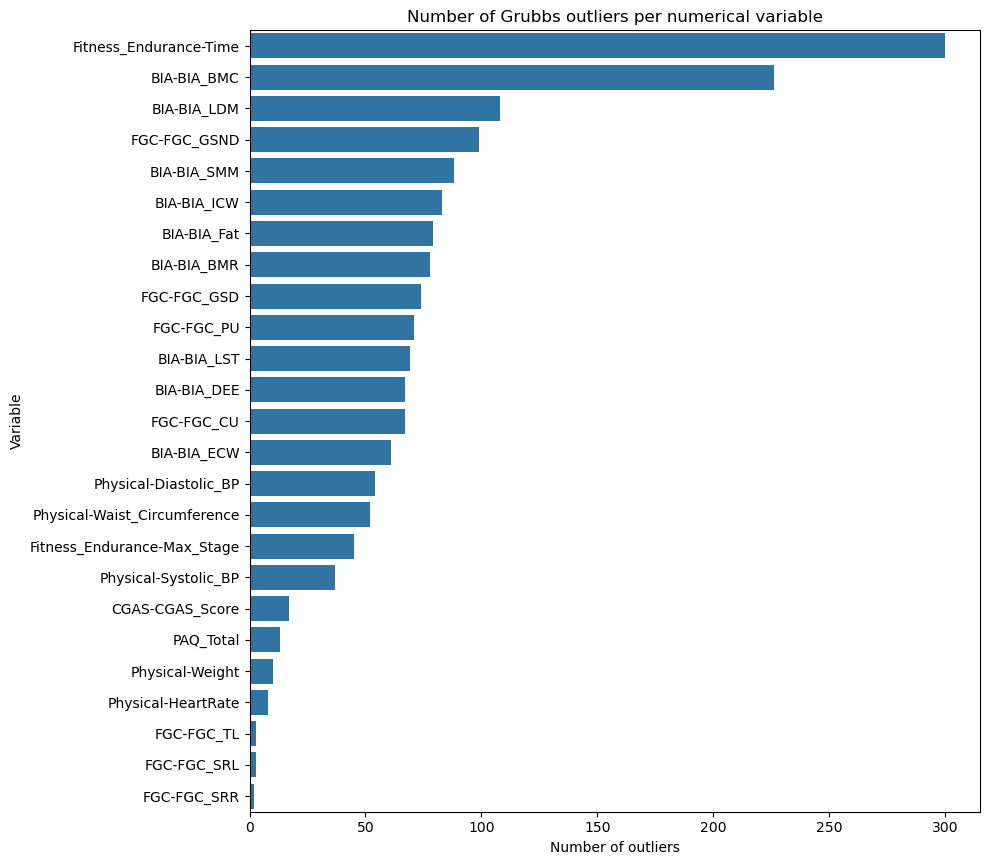

In [13]:
plt.figure(figsize=(10, max(6, 0.35 * len(grubbs_summary_outliers))))

sns.barplot(
    data=grubbs_summary_outliers.reset_index().rename(columns={"index": "variable"}),
    x="n_outliers",
    y="variable"
)

plt.title("Number of Grubbs outliers per numerical variable")
plt.xlabel("Number of outliers")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [14]:
grubbs_outlier_count = grubbs_mask.sum(axis=1)

grubbs_outlier_count.value_counts().sort_index()

0    7277
1     864
2     217
3      54
4      22
5      11
6       3
7       5
8       5
9       2
Name: count, dtype: int64

In [15]:
most_suspicious_grubbs_indices = grubbs_outlier_count.sort_values(

    ascending=False

).head(10).index

pd.concat(

    [

        pd.DataFrame({

            "grubbs_outlier_count": grubbs_outlier_count.loc[most_suspicious_grubbs_indices]

        }),

        df.loc[most_suspicious_grubbs_indices, num_cols]

    ],

    axis=1

)

,grubbs_outlier_count,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,...,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time
3774,9,18.0,0.0,71,73.00,238.6,35.977882,106,5,85,...,0.000,3,138.4910,94.1672,334.766,215.4130,3.310000,59,3,468
3205,9,9.0,1.0,50,54.00,70.4,37.499193,75,5,95,...,0.000,2,2457.9100,3108.1700,4683.710,3607.6900,2.010000,51,0,420
3147,8,8.0,0.0,58,48.00,52.8,26.000000,60,6,27,...,0.000,1,118.2810,67.2885,263.831,188.7340,2.518703,49,2,640
2770,8,9.0,0.0,65,56.00,75.6,26.664696,63,2,78,...,0.000,1,118.4660,69.2348,265.959,189.6880,2.010000,56,0,129
2299,8,13.0,1.0,66,65.00,149.2,26.000000,67,5,73,...,0.000,2,125.6940,95.6882,315.215,223.4490,1.650000,66,2,477
3270,8,16.0,0.0,40,73.00,315.0,38.066315,50,5,74,...,129.226,3,79.4738,50.4479,177.560,116.0190,1.960000,61,3,477
3511,8,13.0,1.0,58,61.50,127.0,26.000000,57,5,74,...,0.000,2,428.2640,392.4000,770.511,823.0280,1.250000,67,3,448
2880,7,20.0,0.0,52,70.50,306.4,50.000000,54,5,68,...,126.010,3,74.2231,48.2196,172.497,87.8876,2.010000,63,3,457
3729,7,11.0,1.0,66,55.00,77.0,26.000000,68,5,80,...,0.000,2,112.3290,79.1255,272.430,193.2190,3.130000,57,2,438
3630,7,13.0,1.0,75,65.75,114.8,26.000000,80,5,68,...,0.000,3,103.7750,74.2242,253.311,178.0020,1.810000,50,1,420


### Likelihood Approach

In [18]:
selected_var = num_cols[0]

data = X_scaled[selected_var].values

print("Selected variable:", selected_var)
print("Number of observations:", len(data))

Selected variable: Basic_Demos-Age
Number of observations: 8460


In [19]:
def norm_dist(x, mu, sigma):
    """
    Normal density function.
    """
    return stats.norm.pdf(x, loc=mu, scale=sigma)


def unif_dist(x, min_value, max_value):
    """
    Uniform density over the observed range.
    """
    width = max_value - min_value
    
    if width == 0:
        return 1.0
    
    return 1 / width

In [16]:
def compute_log_likelihood(M, A, lambda_par=0.30, eps=1e-12):
    """
    Computes the log-likelihood of the current partition into:
    - M: majority points
    - A: anomalous points
    
    M is modeled with a Gaussian distribution.
    A is modeled with a uniform distribution.
    """
    
    M = np.array(M)
    A = np.array(A)
    
    if len(M) < 2:
        return -np.inf
    
    mu_M = np.mean(M)
    sigma_M = np.std(M, ddof=1)
    
    if sigma_M == 0:
        sigma_M = eps
    
    min_all = np.min(np.concatenate([M, A])) if len(A) > 0 else np.min(M)
    max_all = np.max(np.concatenate([M, A])) if len(A) > 0 else np.max(M)
    
    # Log-likelihood contribution of majority points
    ll_M = 0
    
    for x in M:
        p = norm_dist(x, mu_M, sigma_M)
        ll_M += np.log((1 - lambda_par) * max(p, eps))
    
    # Log-likelihood contribution of anomalous points
    ll_A = 0
    
    for x in A:
        p = unif_dist(x, min_all, max_all)
        ll_A += np.log(lambda_par * max(p, eps))
    
    return ll_M + ll_A

In [20]:
M = np.copy(data)
A = []

lambda_par = 0.30

ll_initial = compute_log_likelihood(M, A, lambda_par=lambda_par)

ll_initial

np.float64(-15021.690046185899)

In [21]:
i = 0

M_trial = np.delete(M, i)
A_trial = list(A) + [M[i]]

ll_trial = compute_log_likelihood(M_trial, A_trial, lambda_par=lambda_par)

delta_ll = ll_initial - ll_trial

print("Original value:", M[i])
print("Initial log-likelihood:", ll_initial)
print("Trial log-likelihood:", ll_trial)
print("Delta:", delta_ll)

Original value: -1.4660051499288242
Initial log-likelihood: -15021.690046185899
Trial log-likelihood: -15022.103050753378
Delta: 0.41300456747922


In [22]:
def likelihood_outlier_detection_1d(x, lambda_par=0.30, c=0.20, max_iter=100, verbose=False):
    """
    Likelihood-based outlier detection for one numerical variable.
    
    The algorithm follows the idea:
    - initially all points are in M;
    - for each point in M, try moving it to A;
    - compute the change in log-likelihood;
    - if the change is larger than threshold c, permanently move it to A;
    - repeat until no new outlier is found.
    
    Parameters
    ----------
    x : pandas Series or array-like
        One numerical variable.
    
    lambda_par : float
        Weight of anomalous distribution A.
    
    c : float
        Threshold for declaring a point anomalous.
    
    max_iter : int
        Maximum number of passes over the data.
    
    verbose : bool
        If True, prints each detected outlier.
    
    Returns
    -------
    outlier_indices : list
        Original indices of detected outliers.
    
    history : pandas DataFrame
        Iteration-level information.
    """
    
    x_series = pd.Series(x).dropna()
    
    M = x_series.copy()
    A = pd.Series(dtype=float)
    
    outlier_indices = []
    history = []
    
    iteration = 1
    changed = True
    
    while changed and iteration <= max_iter:
        changed = False
        
        # Work on a copy of the current majority indices
        current_indices = list(M.index)
        
        for idx in current_indices:
            if idx not in M.index:
                continue
            
            ll_current = compute_log_likelihood(
                M.values,
                A.values,
                lambda_par=lambda_par
            )
            
            candidate_value = M.loc[idx]
            
            M_trial = M.drop(index=idx)
            A_trial = pd.concat([A, pd.Series([candidate_value], index=[idx])])
            
            ll_trial = compute_log_likelihood(
                M_trial.values,
                A_trial.values,
                lambda_par=lambda_par
            )
            
            # Same logic as professor's code:
            # delta = ll_current - ll_trial
            delta_ll = ll_current - ll_trial
            
            is_outlier = delta_ll > c
            
            history.append({
                "iteration": iteration,
                "index": idx,
                "value": candidate_value,
                "ll_current": ll_current,
                "ll_trial": ll_trial,
                "delta_ll": delta_ll,
                "is_outlier": is_outlier
            })
            
            if is_outlier:
                outlier_indices.append(idx)
                M = M_trial
                A = A_trial
                changed = True
                
                if verbose:
                    print(
                        f"Iteration {iteration} | index {idx} | "
                        f"value {candidate_value:.4f} | delta {delta_ll:.4f} | outlier"
                    )
        
        iteration += 1
    
    history = pd.DataFrame(history)
    
    return outlier_indices, history

In [24]:
likelihood_results = {}
likelihood_mask = pd.DataFrame(False, index=df.index, columns=num_cols)

lambda_par = 0.30
c_threshold = 0.20

for col in num_cols:
    outlier_indices, history = likelihood_outlier_detection_1d(
        X_scaled[col],
        lambda_par=lambda_par,
        c=c_threshold,
        max_iter=10,
        verbose=False
    )
    
    likelihood_results[col] = {
        "n_outliers": len(outlier_indices),
        "outlier_indices": outlier_indices,
        "history": history
    }
    
    likelihood_mask.loc[outlier_indices, col] = True

KeyboardInterrupt: 

In [ ]:
likelihood_summary = pd.DataFrame({
    "n_outliers": likelihood_mask.sum(axis=0),
    "perc_outliers": likelihood_mask.mean(axis=0) * 100
})

likelihood_summary = likelihood_summary.sort_values(
    "n_outliers",
    ascending=False
)

likelihood_summary

In [ ]:
likelihood_summary_outliers = likelihood_summary[
    likelihood_summary["n_outliers"] > 0
]

likelihood_summary_outliers

In [ ]:
plt.figure(figsize=(10, max(6, 0.35 * len(likelihood_summary_outliers))))

sns.barplot(
    data=likelihood_summary_outliers.reset_index().rename(columns={"index": "variable"}),
    x="n_outliers",
    y="variable"
)

plt.title("Number of Likelihood Approach outliers per numerical variable")
plt.xlabel("Number of outliers")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [ ]:
likelihood_outlier_count = likelihood_mask.sum(axis=1)

likelihood_outlier_count.value_counts().sort_index()

In [ ]:
most_suspicious_likelihood_indices = likelihood_outlier_count.sort_values(
    ascending=False
).head(10).index

pd.concat(
    [
        pd.DataFrame({
            "likelihood_outlier_count": likelihood_outlier_count.loc[most_suspicious_likelihood_indices]
        }),
        df.loc[most_suspicious_likelihood_indices, num_cols]
    ],
    axis=1
)